In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1 saal ka daily sales data generate karte hain testing ke liye
dates = pd.date_range(start="2025-01-01", end="2025-12-31")
np.random.seed(42)
sales = np.random.randint(100, 500, size=len(dates)) + np.sin(np.linspace(0, 20, len(dates))) * 50

# Dataframe banana
df = pd.DataFrame({'Date': dates, 'Sales': sales})
print("--- Data ke pehle 5 rows ---")
print(df.head())

--- Data ke pehle 5 rows ---
        Date       Sales
0 2025-01-01  202.000000
1 2025-01-02  450.745871
2 2025-01-03  375.483454
3 2025-01-04  214.204487
4 2025-01-05  181.900757


In [25]:
# Convert Date column to standard datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract time-based features from the Date column
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday

# Create a Lag Feature (Sales from the previous day)
df['Prev_Day_Sales'] = df['Sales'].shift(1)

# Drop the first row since it contains a NaN value due to shifting
df.dropna(inplace=True)

print("--- Dataset After Feature Engineering ---")
print(df.head())

--- Dataset After Feature Engineering ---
        Date       Sales  Year  Month  Day  DayOfWeek  Prev_Day_Sales
1 2025-01-02  450.745871  2025      1    2          3      202.000000
2 2025-01-03  375.483454  2025      1    3          4      450.745871
3 2025-01-04  214.204487  2025      1    4          5      375.483454
4 2025-01-05  181.900757  2025      1    5          6      214.204487
5 2025-01-06  301.564126  2025      1    6          0      181.900757


In [26]:
print(df.tail())

          Date       Sales  Year  Month  Day  DayOfWeek  Prev_Day_Sales
360 2025-12-27  331.100832  2025     12   27          5      172.400203
361 2025-12-28  189.680429  2025     12   28          6      331.100832
362 2025-12-29  159.134226  2025     12   29          0      189.680429
363 2025-12-30  315.457836  2025     12   30          1      159.134226
364 2025-12-31  364.647263  2025     12   31          2      315.457836


In [29]:
# Import train_test_split and metrics directly inside this cell
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Define input features (X) and target variable (y)
X = df[['Year', 'Month', 'Day', 'DayOfWeek', 'Prev_Day_Sales']]
y = df['Sales']

# Split the data into 80% training and 20% testing sets without shuffling (to preserve time order)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Initialize and train the Machine Learning model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test dataset
predictions = model.predict(X_test)

# Evaluate the model using Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, predictions)
print(f"Model Training Complete.")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Model Training Complete.
Mean Absolute Error (MAE): 126.24


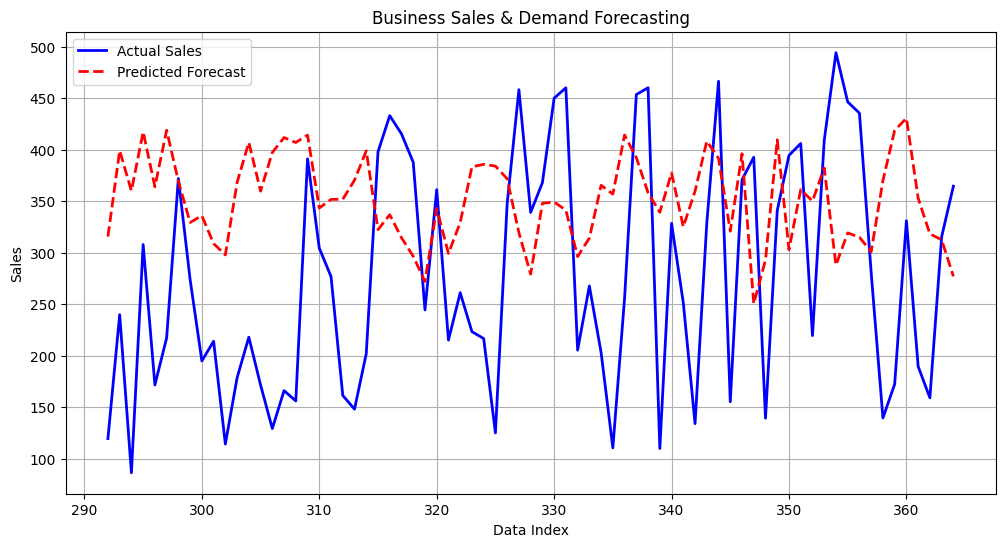

In [31]:
# Plotting the results to visualize the forecast
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label="Actual Sales", color="blue", linewidth=2)
plt.plot(y_test.index, predictions, label="Predicted Forecast", color="red", linestyle="--", linewidth=2)

# Adding graph details
plt.title("Business Sales & Demand Forecasting")
plt.xlabel("Data Index")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

# Display the final plot
plt.show()

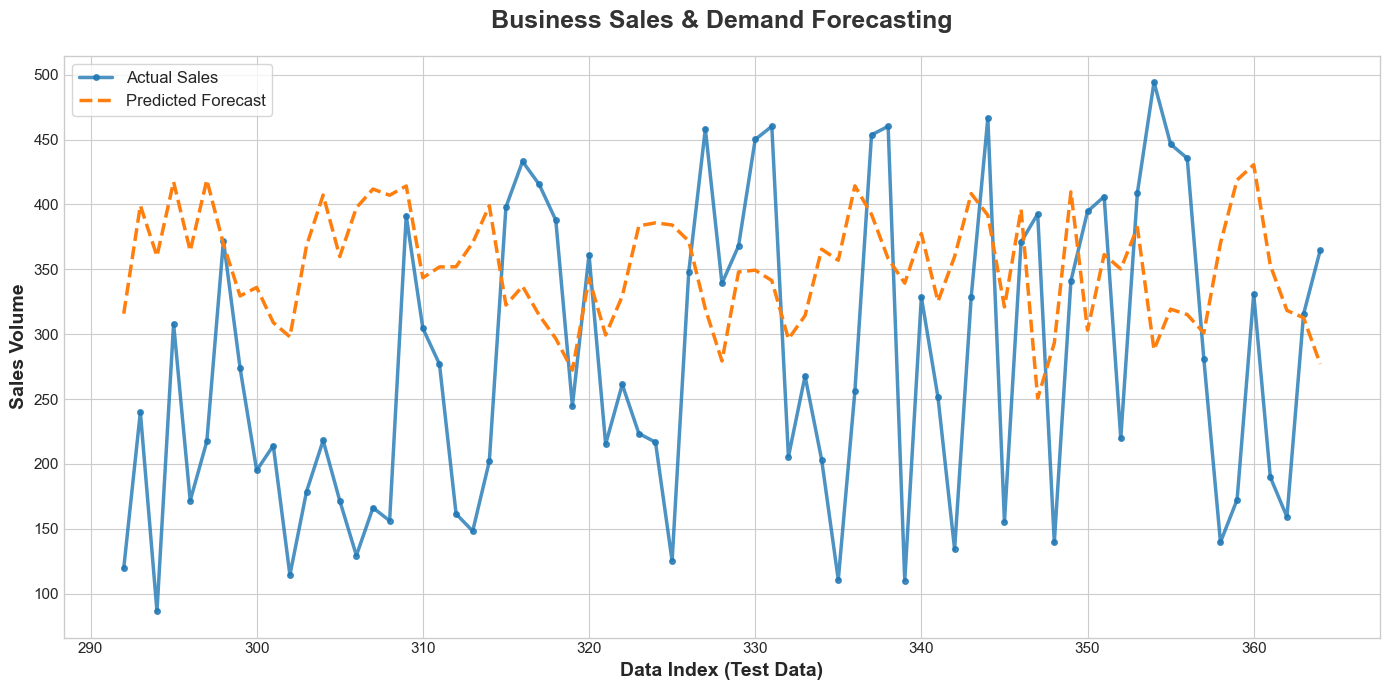

In [32]:
# Is cell mein graph ko styling dene ke liye kuch lines add kari hain
import matplotlib.style as style

# Standard professional plot standard switch karte hain
style.use('seaborn-v0_8-whitegrid')

# Figsize, title professional set karna
plt.figure(figsize=(14, 7), dpi=100)

# Plots customize: Color, linewidth, marker styles
plt.plot(y_test.index, y_test.values, label="Actual Sales", color="#1f77b4", linewidth=2.5, marker='o', markersize=4, alpha=0.8)
plt.plot(y_test.index, predictions, label="Predicted Forecast", color="#ff7f0e", linestyle="--", linewidth=2.5)

# Adding graph details with better styling
plt.title("Business Sales & Demand Forecasting", fontsize=18, fontweight='bold', color="#333333", pad=20)
plt.xlabel("Data Index (Test Data)", fontsize=14, fontweight='bold')
plt.ylabel("Sales Volume", fontsize=14, fontweight='bold')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Legend professional look
plt.legend(frameon=True, fontsize=12, facecolor='white', edgecolor='#cccccc', loc='upper left')

# Display the final polished plot
plt.tight_layout()
plt.show()